# Install Dependencies and Import Packages

In [26]:
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install pyg-lib torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.2.0+cu121.html
!pip install networkx huggingface_hub

Looking in links: https://data.pyg.org/whl/torch-2.2.0+cu121.html


In [27]:
import torch
from torch_geometric.utils import from_networkx, negative_sampling
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
import networkx as nx
import pickle
from huggingface_hub import hf_hub_download
from google.colab import userdata

# Load Dataset from Hugging Face

In [28]:
# authenticate and download graph and embeddings from hugging face
hf_token = userdata.get('HF_TOKEN')

graph_path = hf_hub_download(
    repo_id="uvmdls2026/wikipedia-semantic-graph",
    filename="v3_10000_pages/page_graph.gpickle",
    repo_type="dataset",
    token=hf_token
)

emb_path = hf_hub_download(
    repo_id="uvmdls2026/wikipedia-semantic-graph",
    filename="v3_10000_pages/page_embeddings.pt",
    repo_type="dataset",
    token=hf_token
)

with open(graph_path, "rb") as f:
    G = pickle.load(f)

emb = torch.load(emb_path, map_location="cpu")

In [29]:
# show info about graph
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Directed:", G.is_directed())

node = list(G.nodes())[0]

print(type(node))
print(G.nodes[node])

Nodes: 10000
Edges: 154986
Directed: True
<class 'int'>
{'title': 'Ancient Rome', 'categories': ['5th-century disestablishments', '8th-century BC establishments in Italy', 'Ancient Rome', 'Ancient history', 'Classical civilizations', 'Former empires', 'States and territories disestablished in the 5th century', 'Use British English from February 2025']}


In [30]:
# show info about embeddings
print(type(emb))

if isinstance(emb, torch.Tensor):
    print("Tensor shape:", emb.shape)

elif isinstance(emb, dict):
    print("Dict example keys:", list(emb.keys())[:5])

print(type(emb["embeddings"]))
print(emb["embeddings"].shape)

print(type(emb["page_ids"]))
print(len(emb["page_ids"]))

<class 'dict'>
Dict example keys: ['page_ids', 'embeddings', 'model_name', 'avg_text_length_words']
<class 'torch.Tensor'>
torch.Size([10000, 384])
<class 'list'>
10000


Convert NetworkX -> PyG format

In [31]:
for u, v in G.edges():
    G[u][v].clear()

data = from_networkx(G)

print(data)

Data(edge_index=[2, 154986], title=[10000], categories=[10000], num_nodes=10000)


Attach embeddings

In [32]:
page_ids = emb["page_ids"]
embedding_tensor = emb["embeddings"]

pageid_to_embedding = {
    pid: embedding_tensor[i]
    for i, pid in enumerate(page_ids)
}

Construct feature matrix

In [33]:
embedding_dim = embedding_tensor.shape[1]

node_list = list(G.nodes())

x = torch.zeros((len(node_list), embedding_dim))

missing = 0

for i, node_id in enumerate(node_list):

    if node_id in pageid_to_embedding:
        x[i] = pageid_to_embedding[node_id]
    else:
        missing += 1

print("Missing embeddings:", missing)

data.x = x.float()

print(data.x.shape)
print(data.edge_index.shape)

Missing embeddings: 0
torch.Size([10000, 384])
torch.Size([2, 154986])


# Define GraphSAGE model for training

In [34]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()

        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data = data.to(device)
model = GraphSAGE(384, 128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [35]:
def train():
    model.train()
    optimizer.zero_grad()

    z = model(data.x, data.edge_index)

    pos_edge = data.edge_index

    neg_edge = negative_sampling(
        edge_index=pos_edge,
        num_nodes=data.num_nodes,
        num_neg_samples=pos_edge.size(1)
    )

    pos_score = (z[pos_edge[0]] * z[pos_edge[1]]).sum(dim=1)
    neg_score = (z[neg_edge[0]] * z[neg_edge[1]]).sum(dim=1)

    loss = (
        F.binary_cross_entropy_with_logits(
            pos_score,
            torch.ones_like(pos_score)
        )
        +
        F.binary_cross_entropy_with_logits(
            neg_score,
            torch.zeros_like(neg_score)
        )
    )

    loss.backward()
    optimizer.step()

    return loss.item()

# Run Training

In [39]:
# Initialize the losses list and run the training loop
losses = []
for epoch in range(30):
    loss = train()
    losses.append(loss)
    print(f"Epoch {epoch:03d} | Loss {loss:.4f}")

Epoch 000 | Loss 1.1289
Epoch 001 | Loss 1.1257
Epoch 002 | Loss 1.1261
Epoch 003 | Loss 1.1246
Epoch 004 | Loss 1.1220
Epoch 005 | Loss 1.1171
Epoch 006 | Loss 1.1139
Epoch 007 | Loss 1.1097
Epoch 008 | Loss 1.1045
Epoch 009 | Loss 1.0996
Epoch 010 | Loss 1.0967
Epoch 011 | Loss 1.0902
Epoch 012 | Loss 1.0864
Epoch 013 | Loss 1.0810
Epoch 014 | Loss 1.0761
Epoch 015 | Loss 1.0706
Epoch 016 | Loss 1.0672
Epoch 017 | Loss 1.0655
Epoch 018 | Loss 1.0623
Epoch 019 | Loss 1.0585
Epoch 020 | Loss 1.0525
Epoch 021 | Loss 1.0513
Epoch 022 | Loss 1.0513
Epoch 023 | Loss 1.0460
Epoch 024 | Loss 1.0435
Epoch 025 | Loss 1.0411
Epoch 026 | Loss 1.0354
Epoch 027 | Loss 1.0350
Epoch 028 | Loss 1.0324
Epoch 029 | Loss 1.0311


# Plot Training Loss


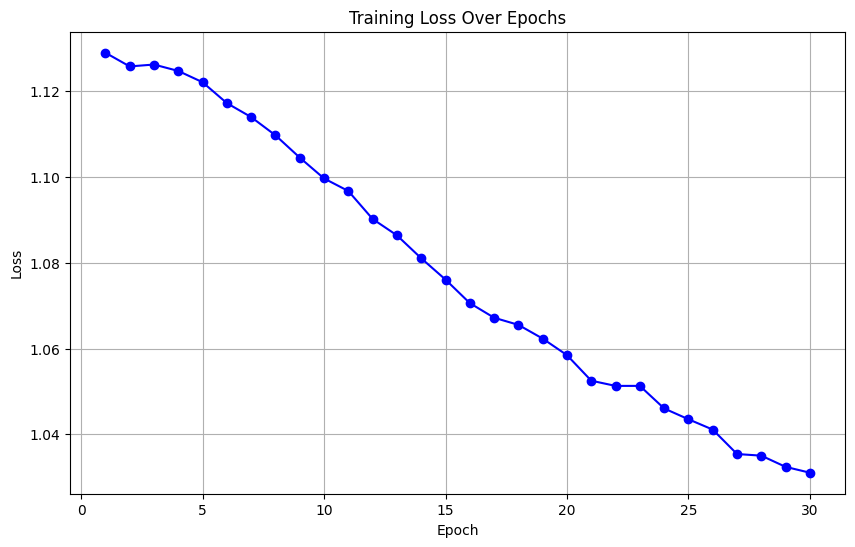

In [40]:
# Create a list of epoch numbers
epochs = range(1, len(losses) + 1)

# Plot the training loss
plt.figure(figsize=(10, 6))
plt.plot(epochs, losses, marker='o', linestyle='-', color='b')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


# Training Summary

This training stage performs **unsupervised GraphSAGE representation learning** to refine pretrained Wikipedia text embeddings using hyperlink graph structure. The objective is not prediction yet, but to produce **structure-aware node embeddings** suitable for downstream navigation or ranking models.

Training loss was recorded across 30 epochs and plotted as *Training Loss Over Epochs*. The decreasing loss indicates that node embeddings are successfully learning to become more similar to structurally related pages (linked neighbors) and more distinct from unrelated pages. In this context, loss reduction confirms effective integration of **semantic similarity + graph topology**.

### Implication

Convergence of the loss demonstrates that the dataset, graph construction, and training pipeline are functioning correctly and have produced usable graph-informed embeddings — the primary goal of this stage.

### Next Steps

Use the learned embeddings as fixed inputs for downstream supervised or ranking-based navigation training rather than traditional validation-based model evaluation at this phase.
